In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style="whitegrid")

df = pd.read_csv('../data/processed/insurance_features.csv')
print("Shape:", df.shape)

Shape: (99989, 17)


In [2]:
# Definir faixas de risco com base nos percentis
p33 = df['charges'].quantile(0.33)
p66 = df['charges'].quantile(0.66)

print(f"Corte Baixo/Médio:  ${p33:,.2f} (percentil 33)")
print(f"Corte Médio/Alto:   ${p66:,.2f} (percentil 66)")

def classificar_risco(valor):
    if valor <= p33:
        return 0  # Baixo
    elif valor <= p66:
        return 1  # Médio
    else:
        return 2  # Alto

df['risk_class'] = df['charges'].apply(classificar_risco)

# Verificar distribuição
labels = {0: 'Baixo', 1: 'Médio', 2: 'Alto'}
print("\nDistribuição das classes:")
for k, v in labels.items():
    n = (df['risk_class'] == k).sum()
    print(f"  {v}: {n:,} ({n/len(df)*100:.1f}%)")
    
print(f"\nCusto médio por classe:")
for k, v in labels.items():
    media = df[df['risk_class'] == k]['charges'].mean()
    print(f"  {v}: ${media:,.0f}")

Corte Baixo/Médio:  $10,543.53 (percentil 33)
Corte Médio/Alto:   $17,530.85 (percentil 66)

Distribuição das classes:
  Baixo: 32,997 (33.0%)
  Médio: 32,996 (33.0%)
  Alto: 33,996 (34.0%)

Custo médio por classe:
  Baixo: $8,002
  Médio: $13,596
  Alto: $34,757


In [3]:
X = df.drop(columns=['charges', 'log_charges', 'risk_class'])
y = df['risk_class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape[0]:,} linhas")
print(f"Teste:  {X_test.shape[0]:,} linhas")
print(f"Features: {X_train.shape[1]}")

Treino: 79,991 linhas
Teste:  19,998 linhas
Features: 15


In [4]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=" * 50)
print("  RANDOM FOREST — CLASSIFICAÇÃO DE RISCO")
print("=" * 50)
print(classification_report(y_test, y_pred_rf,
      target_names=['Baixo', 'Médio', 'Alto']))

  RANDOM FOREST — CLASSIFICAÇÃO DE RISCO
              precision    recall  f1-score   support

       Baixo       0.79      0.80      0.80      6600
       Médio       0.55      0.75      0.64      6599
        Alto       0.94      0.60      0.74      6799

    accuracy                           0.72     19998
   macro avg       0.76      0.72      0.72     19998
weighted avg       0.76      0.72      0.72     19998



Falsos negativos críticos (Alto→Baixo): 0
→ 0.0% dos pacientes de alto custo
  foram classificados como baixo risco
→ Cada um representa risco financeiro
  não provisionado para a seguradora


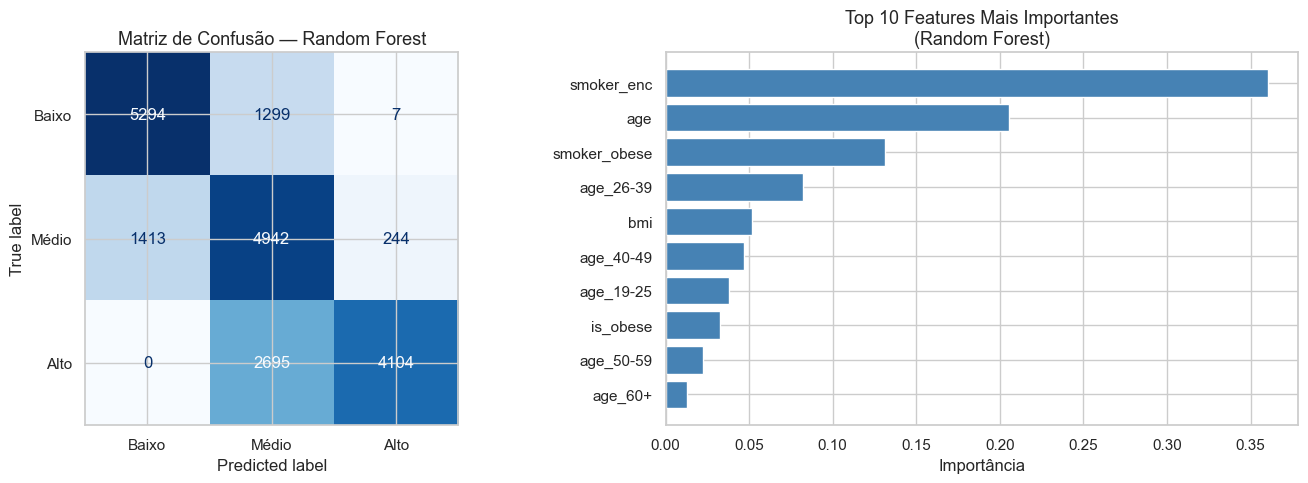

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Baixo','Médio','Alto'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusão — Random Forest', fontsize=13)

# Falsos negativos — alto custo classificado como baixo
fn_critico = cm[2][0]
total_alto  = cm[2].sum()
print(f"Falsos negativos críticos (Alto→Baixo): {fn_critico:,}")
print(f"→ {fn_critico/total_alto*100:.1f}% dos pacientes de alto custo\n  foram classificados como baixo risco")
print(f"→ Cada um representa risco financeiro\n  não provisionado para a seguradora")

# Importância das features
importancias = pd.Series(rf.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=True).tail(10)
axes[1].barh(importancias.index, importancias.values, color='steelblue', edgecolor='white')
axes[1].set_title('Top 10 Features Mais Importantes\n(Random Forest)', fontsize=13)
axes[1].set_xlabel('Importância')

plt.tight_layout()
plt.show()

In [6]:
import pickle

with open('../data/processed/rf_classifier.pkl', 'wb') as f:
    pickle.dump(rf, f)

# Salvar cortes de risco
cortes = {'p33': p33, 'p66': p66}
import json
with open('../data/processed/risk_thresholds.json', 'w') as f:
    json.dump(cortes, f)

print("Modelo salvo em data/processed/rf_classifier.pkl ✅")
print("Cortes salvos em data/processed/risk_thresholds.json ✅")
print(f"\nCorte Baixo/Médio: ${p33:,.2f}")
print(f"Corte Médio/Alto:  ${p66:,.2f}")

Modelo salvo em data/processed/rf_classifier.pkl ✅
Cortes salvos em data/processed/risk_thresholds.json ✅

Corte Baixo/Médio: $10,543.53
Corte Médio/Alto:  $17,530.85
